UNIFIED FANO-FIBONACCI AUTOMATON & NUMBER-THEORETIC PROOF

Base   N_active   GCD(N,7)   GCD(N,3)   GCD(N,5)   Info Density    Status
-------------------------------------------------------------------------------------
2      1          1          1          1          0.9068          MINIMAL (No Redundancy)
8      7          7          1          1          0.9230          DEGENERATE TRAP (GCD=7)
10     9          1          3          1          0.9883          RESONANCE TRAP (Shares Fib factors)


/tmp/ipykernel_4570/382086370.py:139: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', base)


12     11         1          1          1          0.9823          COPRIME / OPTIMAL (Goldilocks)
16     15         1          3          5          0.9728          RESONANCE TRAP (Shares Fib factors)

✓ Saved: unified_fano_analysis_fixed.png


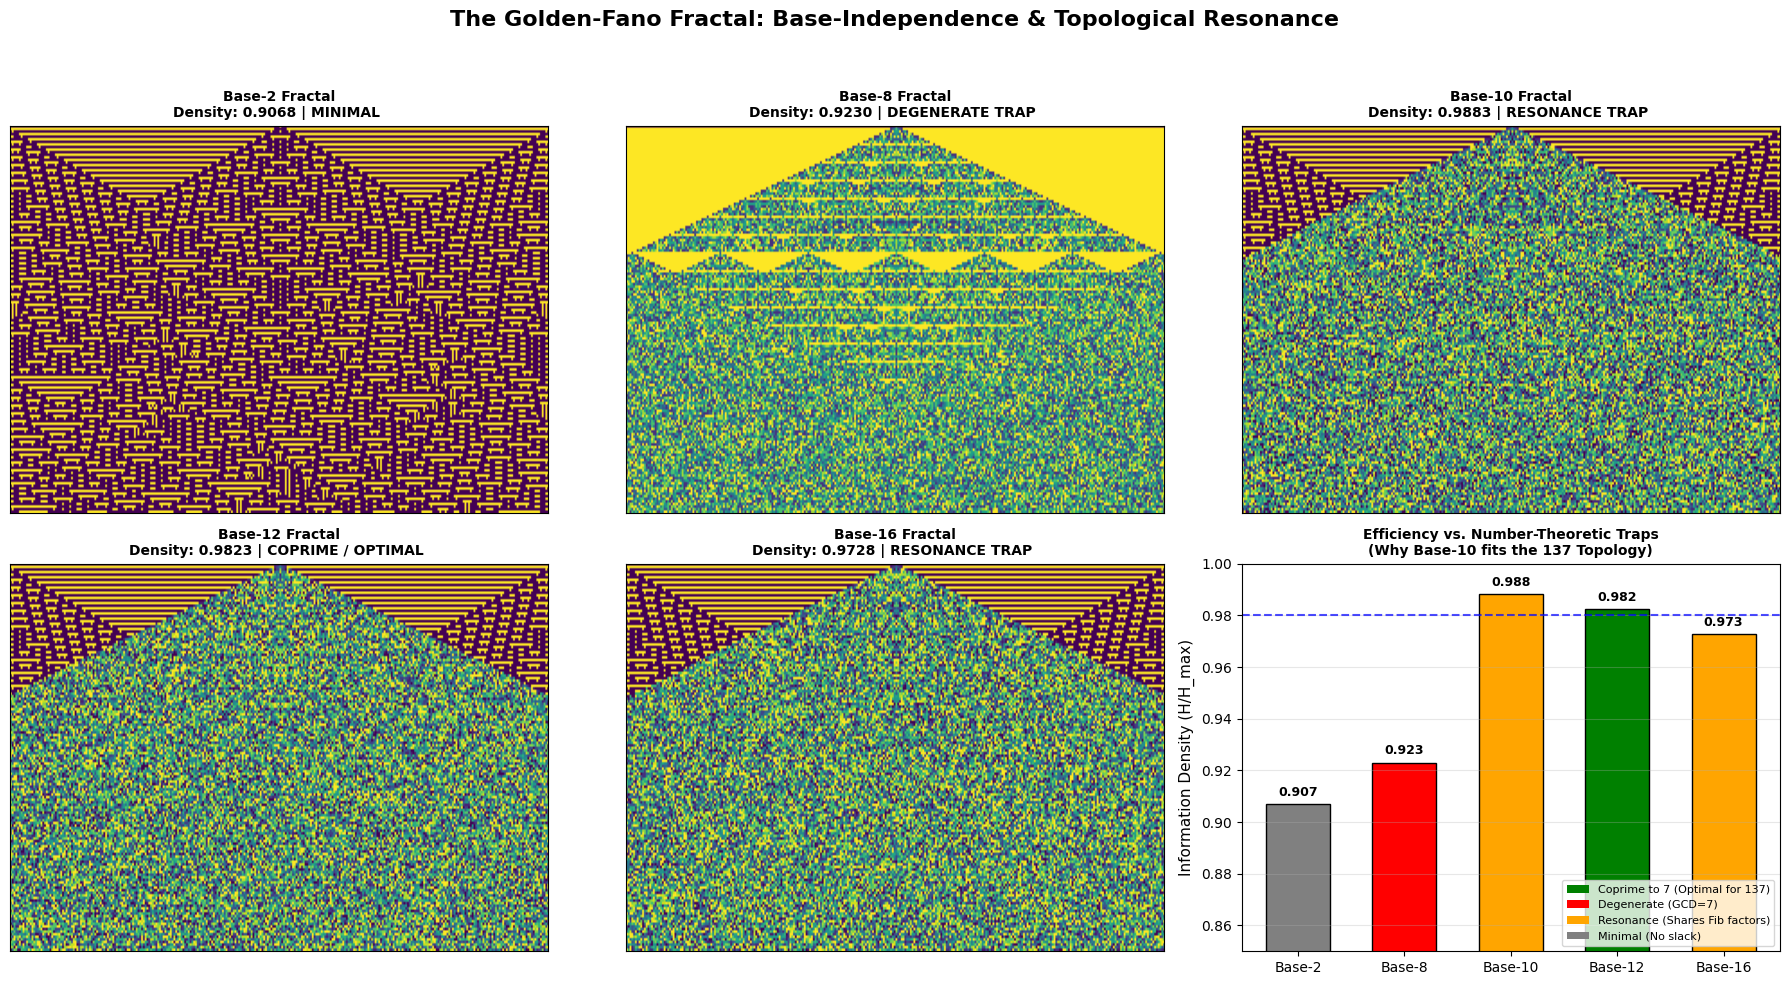

In [3]:
"""
unified_fano_analysis_fixed.py
==============================
Fixed layout and clarified "Why 137?" argument.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import math

print("=" * 70)
print("UNIFIED FANO-FIBONACCI AUTOMATON & NUMBER-THEORETIC PROOF")
print("=" * 70)

# =============================================================================
# 1. THE GOLDEN-FANO RULE (Rule 137 / Fano-Fibonacci CA)
# =============================================================================

def run_fano_fibonacci_ca(base, steps=150, width=300):
    """Runs the Cellular Automaton for a given Base."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1 # Seed

    # Fibonacci Weights for radius-3 neighborhood (7 cells)
    W = np.array([1, 2, 3, 5, 3, 2, 1])

    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]

        # Rule A: The Fano-Check (Maintenance Channel)
        reserved_mask = (weighted_sum % 7 == 0)

        # Rule B: The Golden Expansion (Fractal Growth)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

# =============================================================================
# 2. INFORMATION DENSITY & NUMBER-THEORETIC ANALYSIS
# =============================================================================

def analyze_fractal(grid, base):
    """Calculates Shannon Entropy and Information Density."""
    steps, width = grid.shape
    center = width // 2
    cone_width = steps // 2

    fractal_data = []
    for t in range(steps):
        start = max(0, center - cone_width - t)
        end = min(width, center + cone_width + t + 1)
        fractal_data.extend(grid[t, start:end])

    fractal_data = np.array(fractal_data)
    counts = np.bincount(fractal_data, minlength=base)
    probs = counts / np.sum(counts)
    probs = probs[probs > 0]

    H = entropy(probs, base=2)
    H_max = np.log2(base)
    info_density = H / H_max

    return H, info_density

def calculate_number_theory_metrics(base):
    """Calculates the mathematical reasons for efficiency or inefficiency."""
    n_active = base - 1
    gcd_fano = math.gcd(n_active, 7)
    is_degenerate = (gcd_fano > 1)
    gcd_3 = math.gcd(n_active, 3)
    gcd_5 = math.gcd(n_active, 5)
    is_resonant = (gcd_3 > 1 or gcd_5 > 1)
    return n_active, gcd_fano, is_degenerate, gcd_3, gcd_5, is_resonant

# =============================================================================
# 3. SIMULATION AND VISUALIZATION
# =============================================================================

# We include Base-2, Base-8, Base-10, Base-12, Base-16
bases_to_test = [2, 8, 10, 12, 16]

# Create a 2x3 grid.
# Row 1: Base-2, Base-8, Base-10
# Row 2: Base-12, Base-16, Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("The Golden-Fano Fractal: Base-Independence & Topological Resonance",
             fontsize=16, fontweight='bold', y=0.98)

print(f"\n{'Base':<6} {'N_active':<10} {'GCD(N,7)':<10} {'GCD(N,3)':<10} {'GCD(N,5)':<10} {'Info Density':<15} {'Status'}")
print("-" * 85)

densities = []
labels = []
bar_colors = []

for idx, base in enumerate(bases_to_test):
    # Determine subplot location
    if idx == 0: ax = axes[0, 0]
    elif idx == 1: ax = axes[0, 1]
    elif idx == 2: ax = axes[0, 2]
    elif idx == 3: ax = axes[1, 0]
    elif idx == 4: ax = axes[1, 1]

    # Run CA
    grid = run_fano_fibonacci_ca(base, steps=150, width=300)

    # Analyze
    H, density = analyze_fractal(grid, base)
    densities.append(density)
    labels.append(f"Base-{base}")

    # Number Theory
    n_active, gcd_fano, is_deg, gcd_3, gcd_5, is_res = calculate_number_theory_metrics(base)

    # Determine color and status for bar chart
    if base == 2:
        status = "MINIMAL (No Redundancy)"; color = 'gray'
    elif is_deg:
        status = "DEGENERATE TRAP (GCD=7)"; color = 'red'
    elif is_res:
        status = "RESONANCE TRAP (Shares Fib factors)"; color = 'orange'
    else:
        status = "COPRIME / OPTIMAL (Goldilocks)"; color = 'green'

    bar_colors.append(color)

    print(f"{base:<6} {n_active:<10} {gcd_fano:<10} {gcd_3:<10} {gcd_5:<10} {density:<15.4f} {status}")

    # Plot Fractal
    cmap = plt.cm.get_cmap('viridis', base)
    cmap.set_over('red')
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=base-1, aspect='auto')
    ax.set_title(f"Base-{base} Fractal\nDensity: {density:.4f} | {status.split('(')[0]}", fontweight='bold', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# --- BAR CHART (Bottom Right) ---
ax_bar = axes[1, 2]
bars = ax_bar.bar(labels, densities, color=bar_colors, edgecolor='black', width=0.6)
ax_bar.set_ylabel('Information Density (H/H_max)', fontsize=11)
ax_bar.set_title('Efficiency vs. Number-Theoretic Traps\n(Why Base-10 fits the 137 Topology)', fontweight='bold', fontsize=10)
ax_bar.set_ylim(0.85, 1.0)
ax_bar.axhline(y=0.98, color='blue', linestyle='--', alpha=0.7, label='Universal Limit (~0.98)')

# Add text annotations to bars
for i, (bar, dens) in enumerate(zip(bars, densities)):
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{dens:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Add legend explaining the colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Coprime to 7 (Optimal for 137)'),
    Patch(facecolor='red', label='Degenerate (GCD=7)'),
    Patch(facecolor='orange', label='Resonance (Shares Fib factors)'),
    Patch(facecolor='gray', label='Minimal (No slack)')
]
ax_bar.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax_bar.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("unified_fano_analysis_fixed.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: unified_fano_analysis_fixed.png")
plt.show()